In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
data = pd.read_csv(r"C:\Users\K Madan Mohan Reddy\Desktop\Loan_Default.csv")

((118936, 31), (29734, 31), (118936,), (29734,))

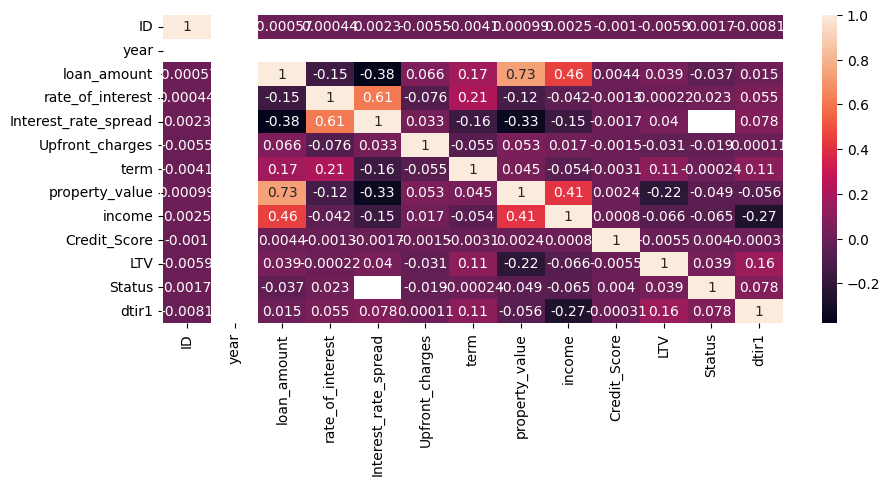

In [ ]:
# Checking for missing values
data.isnull().sum()

# Checking unique values in each column
data.nunique()

# Checking categorical columns
cat_columns = data.select_dtypes(['object', 'category']).columns

# Filtering numerical columns
num_col = list(data.select_dtypes(['int64', 'float64']).columns)

# Finding the correlation between numerical columns
num_data = data[num_col]
cor = num_data.corr()

# Saving the correlation matrix as a JSON file
import json
cor_dict = cor.to_dict()  # Convert the correlation matrix to a dictionary
with open('correlation_matrix.json', 'w') as f:
    json.dump(cor_dict, f)  # Write the dictionary to a JSON file

# Plotting the heatmap using seaborn
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 4))
sns.heatmap(cor, annot=True, cmap='rocket', annot_kws={'fontsize': 10})

# Splitting the data into features and target variable
from sklearn.model_selection import train_test_split
features = data.drop(['Status', 'ID', 'year'], axis=1)
target = data['Status']
x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

x_train.shape, x_test.shape, y_train.shape, y_test.shape


In [11]:
# convert categorical columns by using labelencoding
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

cat_columns=list(features.select_dtypes(['object','category']).columns)
num_col=list(features.select_dtypes(['int64','float64']).columns)
le=LabelEncoder()
cat_transformer= Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('one-hot',OneHotEncoder(handle_unknown='ignore'))
])
num_transformer=Pipeline(steps=[('imputer',SimpleImputer(strategy='median')),
                                ('scaler',StandardScaler())
                               ])
preprocessor=ColumnTransformer(transformers=[('num',num_transformer,num_col),
                                             ('cat',cat_transformer,cat_columns)])


In [15]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb_model)
])
xgb_pipeline.fit(x_train, y_train)


# Prediction
y_pred = xgb_pipeline.predict(x_test)

# Evaluation
print(f"Model Accuracy: {xgb_pipeline.score(x_test, y_test)}\n")

print(f"Confusion Matrix: \n {confusion_matrix(y_test, y_pred)}\n")
print(f"Classification Report : \n {classification_report(y_test, y_pred)}\n")

d:\Madan_MITRAz\MIT Project\Loan Default Prediction\Loan_venv\lib\site-packages\xgboost\core.py:158: UserWarning: [11:50:49] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


AttributeError: 'super' object has no attribute '__sklearn_tags__'